By the help of Grad-CAM and Integrated Gradients, investigate which area of an adversarial example of an image makes your favorite neural network confused.

Compare most important area of an adversarial example with the important area of the original image.

Investigate what will happen if you consider softmax layer for Grad-CAM and the previous-layer of the softmax layer for IG for estimating gradients.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions


## Load Model and Preprocess Image

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
54072/54072 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step


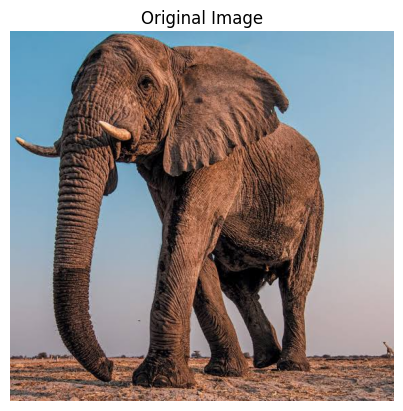

In [2]:
# Load model with pretrained ImageNet weights
model = MobileNetV2(weights='imagenet')
model.trainable = False

img_path = keras.utils.get_file(
    "elephant.jpg", "https://i.ibb.co/SXMs7yM7/elephant.jpg"
)

original_img = image.load_img(img_path)
plt.imshow(original_img) ;
plt.title('Original Image')
plt.axis('off')
plt.show()

# Load and preprocess
def load_img_tensor(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    original_img = img.copy()
    x = image.img_to_array(img)
    x = preprocess_input(x)
    x = np.expand_dims(x, axis=0)
    return tf.convert_to_tensor(x), original_img

img_tensor, original_img = load_img_tensor(img_path)


## Adversarial (FGSM)

In [3]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    prediction = model(img_tensor)
    class_idx = tf.argmax(prediction[0])
    loss = loss_object(tf.one_hot([class_idx], 1000), prediction)

# FGSM
gradient = tape.gradient(loss, img_tensor)
adv_img_tensor = img_tensor + 0.01 * tf.sign(gradient)
adv_img_tensor = tf.clip_by_value(adv_img_tensor, -1.0, 1.0)


## Grad-CAM Function

In [4]:
import cv2

def get_gradcam_heatmap(img_tensor, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap + 1e-8)
    return heatmap.numpy()


## Grad-CAM Heatmaps

In [5]:
last_conv_layer_name = 'Conv_1'

# Grad-CAM heatmaps
heatmap_orig = get_gradcam_heatmap(img_tensor, model, last_conv_layer_name)
heatmap_adv = get_gradcam_heatmap(adv_img_tensor, model, last_conv_layer_name)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


## Generate HeatMap function

In [6]:
def superimpose_heatmap(heatmap, img):
    heatmap = cv2.resize(heatmap, (img.width, img.height))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    return heatmap

original_img_np = np.array(original_img)

# Superimpose heatmaps
heatmap_orig_img = superimpose_heatmap(heatmap_orig, original_img)
heatmap_adv_img = superimpose_heatmap(heatmap_adv, original_img)


## Overlay Heatmaps on Image

In [7]:
def superimpose_heatmap(heatmap, original_img, alpha=0.4):

    if tf.is_tensor(heatmap):
        heatmap = heatmap.numpy()

    heatmap = cv2.resize(heatmap, (original_img.size[0], original_img.size[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    original_np = np.array(original_img)
    superimposed_img = cv2.addWeighted(original_np, 1 - alpha, heatmap_color, alpha, 0)
    return superimposed_img

## Display the image, HeatMap and Overlay with Grad CAM

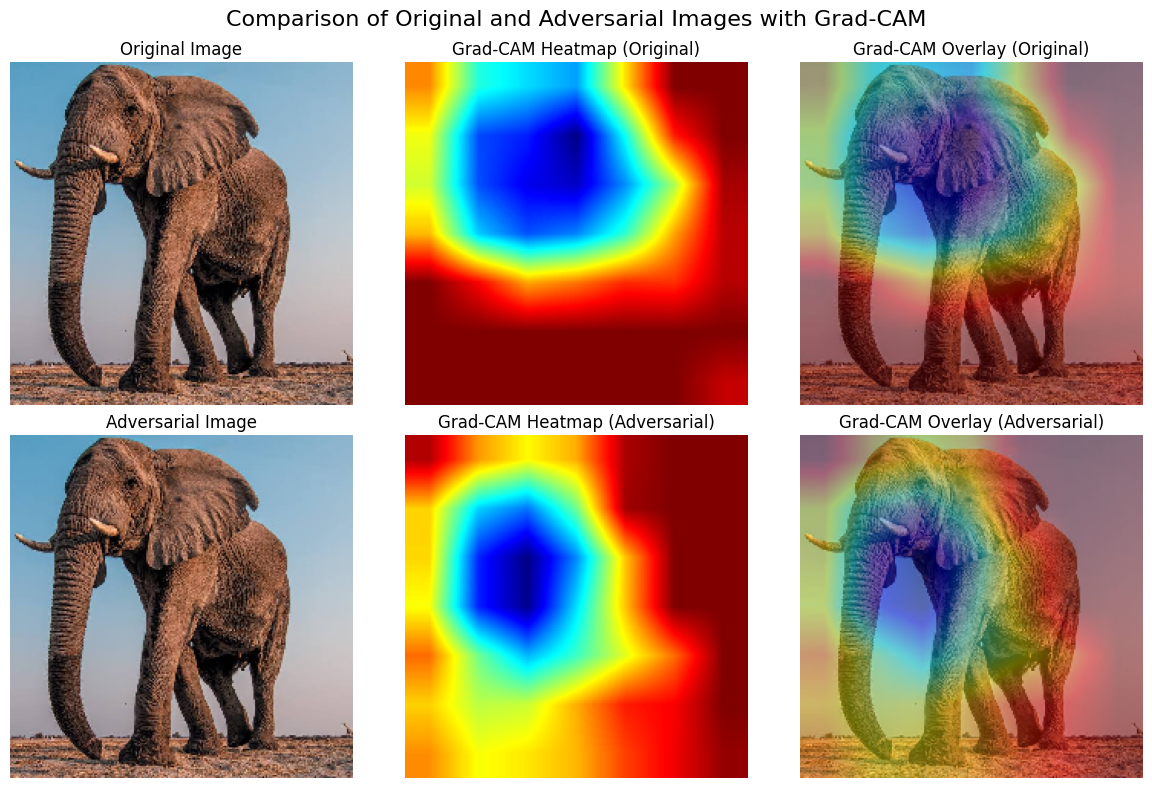

In [8]:
plt.figure(figsize=(12, 8))


plt.subplot(2, 3, 1)
plt.imshow(original_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(heatmap_orig_img)
plt.title('Grad-CAM Heatmap (Original)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(superimpose_heatmap(heatmap_orig, original_img))
plt.title('Grad-CAM Overlay (Original)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(original_img)
plt.title('Adversarial Image')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(heatmap_adv_img)
plt.title('Grad-CAM Heatmap (Adversarial)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(superimpose_heatmap(heatmap_adv, original_img))
plt.title('Grad-CAM Overlay (Adversarial)')
plt.axis('off')

plt.suptitle('Comparison of Original and Adversarial Images with Grad-CAM', fontsize=16)
plt.tight_layout()
plt.show()


# Integrated Gradients (IG)

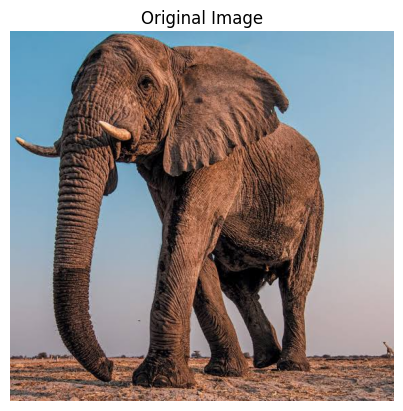

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Original image predictions:
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[('n02504458', 'African_elephant', np.float32(0.6304354)), ('n01871265', 'tusker', np.float32(0.094511524)), ('n02504013', 'Indian_elephant', np.float32(0.084559485)), ('n01704323', 'triceratops', np.float32(0.0035561286)), ('n02090379', 'redbone', np.float32(0.0027914462))]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Adversarial image predictions:
[('n01871265', 'tusker', np.float32(0.14756483)), ('n02504013', 'Indian_elephant', np.float32(0.062263027)), ('n02109047', 'Great_Dane', np.float32(0.04401568)), ('n01704323', 'triceratops', np.float32(0.031423986)), ('n07248320', 'book_jacket', np.float32(0.014690054))]


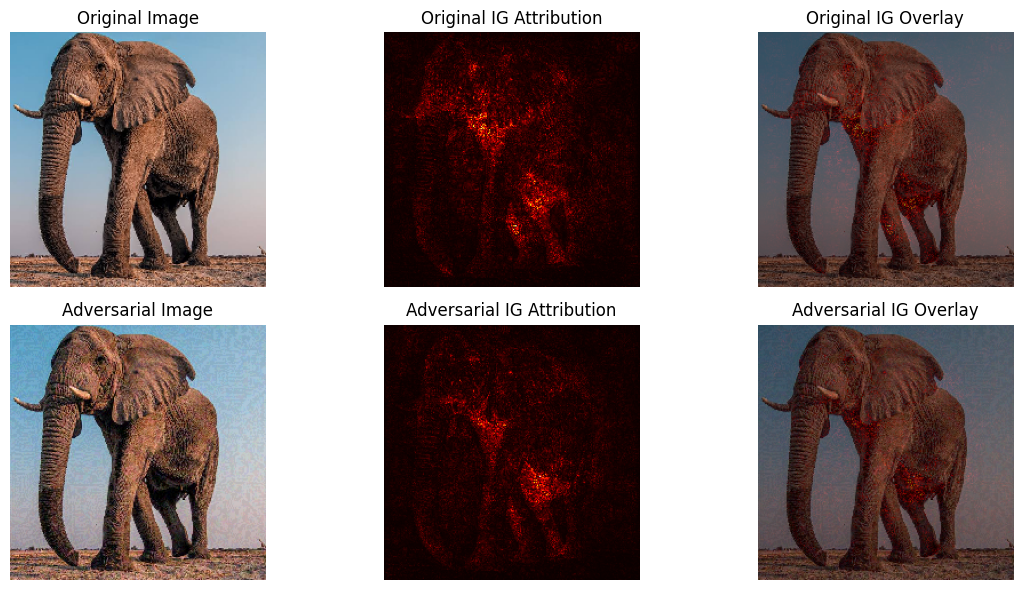

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from PIL import Image

# ==========Load and display image =============
img_path = "elephant.jpg"

# display(img_resized)


img_path = keras.utils.get_file(
    "elephant.jpg", "https://i.ibb.co/SXMs7yM7/elephant.jpg"
)

img = image.load_img(img_path)
plt.imshow(img) ;
plt.title('Original Image')
plt.axis('off')
plt.show()

img = Image.open(img_path)
img_resized = img.resize((512, 512))

# =============Load pre-trained model and preprocess image ==============
model = MobileNetV2(weights="imagenet")
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

#==========Predict on original image ===================
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions[0])
print("Original image predictions:")
print(decode_predictions(predictions, top=5)[0])

# =============Integrated Gradients ==============
def integrated_gradients(model, img_input, target_index, baseline=None, steps=50):
    if baseline is None:
        baseline = tf.zeros(shape=img_input.shape)

    img_input = tf.squeeze(img_input)
    baseline = tf.squeeze(baseline)
    alphas = tf.linspace(0.0, 1.0, steps + 1)
    interpolated = [(baseline + alpha * (img_input - baseline)) for alpha in alphas]
    interpolated = tf.stack(interpolated)
    interpolated = tf.cast(interpolated, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)
        target_preds = preds[:, target_index]

    grads = tape.gradient(target_preds, interpolated)
    avg_grads = tf.reduce_mean(grads[:-1], axis=0)

    ig = (img_input - baseline) * avg_grads
    return ig.numpy()


# =================IG on original image ======================
img_tensor = tf.convert_to_tensor(img_array)
attributions = integrated_gradients(model, img_tensor, predicted_class)
ig_norm = np.sum(np.abs(attributions), axis=-1)
ig_norm = ig_norm / (np.max(ig_norm) + 1e-8)

# =================FGSM adversarial attack ========================
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()
input_tensor = tf.convert_to_tensor(img_array)

with tf.GradientTape() as tape:
    tape.watch(input_tensor)
    prediction = model(input_tensor)
    loss = loss_object(tf.constant([predicted_class]), prediction)

gradient = tape.gradient(loss, input_tensor)
signed_grad = tf.sign(gradient)
epsilon = 0.05
adv_img = input_tensor + epsilon * signed_grad
adv_img = tf.clip_by_value(adv_img, -1.0, 1.0)

# =============Predict on adversarial image ===================
adv_predictions = model.predict(adv_img)
adv_predicted_class = np.argmax(adv_predictions[0])
print("\nAdversarial image predictions:")
print(decode_predictions(adv_predictions, top=5)[0])

# ===================IG on adversarial image =======================
adv_ig = integrated_gradients(model, adv_img, adv_predicted_class)
adv_ig_norm = np.sum(np.abs(adv_ig), axis=-1)
adv_ig_norm = adv_ig_norm / (np.max(adv_ig_norm) + 1e-8)

# ==============Deprocess images for display =======================
def deprocess(img_tensor):
    img = (img_tensor + 1.0) * 127.5
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

original_img_display = deprocess(img_array[0].astype(np.float32))
adv_img_display = deprocess(adv_img[0].numpy())

# ==========Plot all results ================
plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(original_img_display)
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(ig_norm, cmap='hot')
plt.title("Original IG Attribution")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(original_img_display)
plt.imshow(ig_norm, cmap='hot', alpha=0.5)
plt.title("Original IG Overlay")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(adv_img_display)
plt.title("Adversarial Image")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(adv_ig_norm, cmap='hot')
plt.title("Adversarial IG Attribution")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(adv_img_display)
plt.imshow(adv_ig_norm, cmap='hot', alpha=0.5)
plt.title("Adversarial IG Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()

## Grad-CAM with Softmax and IG with Layer Before Softmax

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


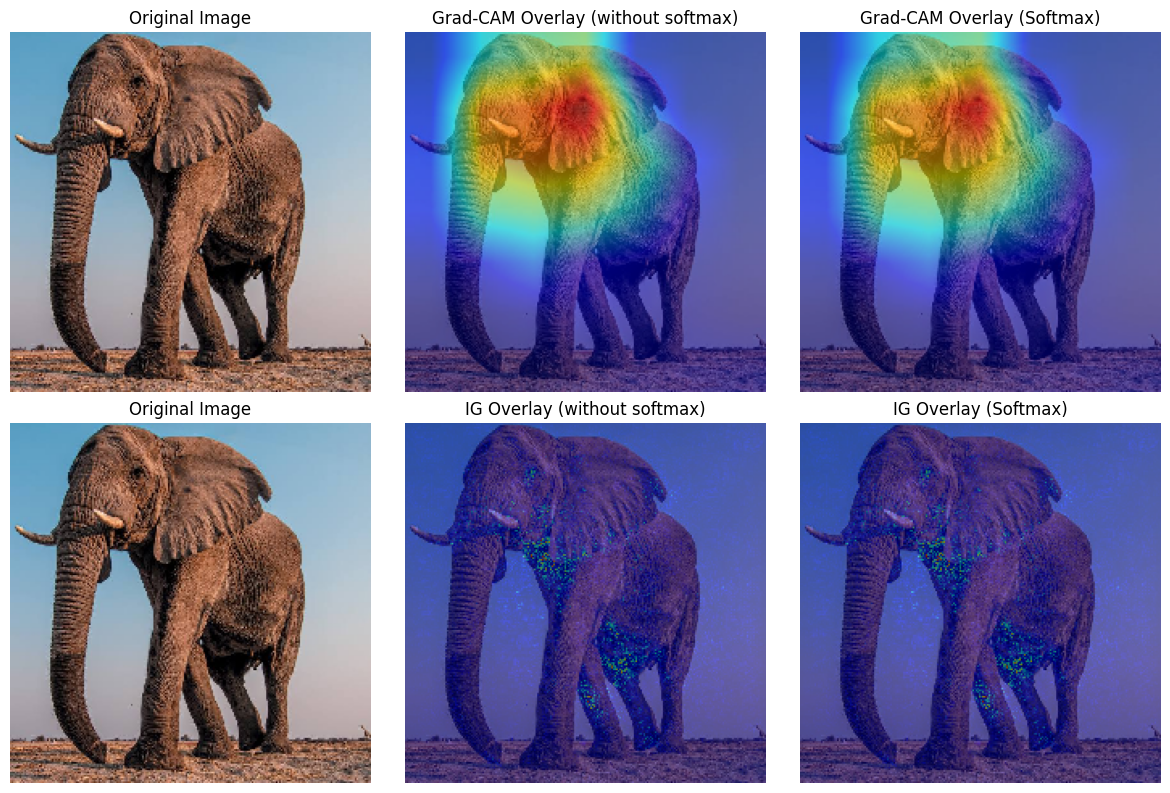

In [16]:
# Load and preprocess image

import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


img_path = keras.utils.get_file(
    "elephant.jpg", "https://ibb.co.com/67GNdsYx"
)

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)
img_tensor = tf.convert_to_tensor(img_array)

# Load model and predict class
model = MobileNetV2(weights="imagenet")
preds = model.predict(img_array)
pred_class = np.argmax(preds[0])

# Grad-CAM without softmax
def grad_cam_logits(model, input_tensor, class_idx):
    grad_model = tf.keras.Model(
        [model.input],
        [model.get_layer("out_relu").output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(input_tensor)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = tf.reduce_mean(conv_output * pooled_grads, axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return cv2.resize(heatmap, (224, 224))

# Grad-CAM with softmax
def grad_cam_softmax(model, input_tensor, class_idx):
    softmax_layer = tf.keras.layers.Softmax()
    grad_model = tf.keras.Model(
        [model.input],
        [model.get_layer("out_relu").output, softmax_layer(model.output)]
    )
    with tf.GradientTape() as tape:
        conv_output, softmax_preds = grad_model(input_tensor)
        loss = softmax_preds[:, class_idx]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = tf.reduce_mean(conv_output * pooled_grads, axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return cv2.resize(heatmap, (224, 224))

# Integrated Gradients
def compute_integrated_gradients(model, input_tensor, class_idx, baseline=None, steps=50, use_softmax=False):
    if baseline is None:
        baseline = tf.zeros_like(input_tensor)

    alphas = tf.linspace(0.0, 1.0, steps + 1)
    alphas_x = alphas[:, tf.newaxis, tf.newaxis, tf.newaxis]
    interpolated = baseline + alphas_x * (input_tensor - baseline)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated)
        if use_softmax:
            preds = tf.nn.softmax(preds)
        target = preds[:, class_idx]

    grads = tape.gradient(target, interpolated)
    avg_grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(avg_grads, axis=0)
    ig = (input_tensor - baseline)[0] * avg_grads
    ig = tf.reduce_sum(tf.abs(ig), axis=-1).numpy()
    ig -= ig.min()
    ig /= ig.max() + 1e-8
    return cv2.resize(ig, (224, 224))

# Overlay heatmap on image
def overlay_heatmap(heatmap, image, cmap='jet', alpha=0.5):
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(cv2.cvtColor(image, cv2.COLOR_RGB2BGR), 1 - alpha, heatmap_color, alpha, 0)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# Deprocess image for display
def deprocess(x):
    x = (x + 1.0) * 127.5
    return np.clip(x, 0, 255).astype(np.uint8)

img_disp = deprocess(img_array[0])

# Plot all results
# Generate heatmaps
heatmap_logits = grad_cam_logits(model, img_tensor, pred_class)
heatmap_softmax = grad_cam_softmax(model, img_tensor, pred_class)
ig_logits = compute_integrated_gradients(model, img_tensor, pred_class, use_softmax=False)
ig_softmax = compute_integrated_gradients(model, img_tensor, pred_class, use_softmax=True)

# Overlay heatmaps
overlay_gc_logits = overlay_heatmap(heatmap_logits, img_disp)
overlay_gc_softmax = overlay_heatmap(heatmap_softmax, img_disp)
overlay_ig_logits = overlay_heatmap(ig_logits, img_disp, cmap='hot')
overlay_ig_softmax = overlay_heatmap(ig_softmax, img_disp, cmap='hot')

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img_disp)
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(overlay_gc_logits)
plt.title("Grad-CAM Overlay (without softmax)")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(overlay_gc_softmax)
plt.title("Grad-CAM Overlay (Softmax)")
plt.axis('off')


plt.subplot(2, 3, 4)
plt.imshow(img_disp)
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(overlay_ig_logits)
plt.title("IG Overlay (without softmax)")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(overlay_ig_softmax)
plt.title("IG Overlay (Softmax)")
plt.axis('off')

plt.tight_layout()
plt.show()